# Demand Forecasting

## Objective

The objective of this notebook is to build a machine learning model that predicts product demand using historical retail transaction data. A Random Forest Regressor is used to estimate future sales quantity based on product, pricing, and time-related features.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/online_retail_II_feature_engineered.csv")

In [3]:

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,MonthName,Quarter,Day,DayOfWeek,Hour,Revenue,TimeOfDay,Season,BasketSize,UniqueProducts
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,83.4,Morning,Winter,166,8
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,81.0,Morning,Winter,166,8
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,81.0,Morning,Winter,166,8
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,100.8,Morning,Winter,166,8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,December,4,1,Tuesday,7,30.0,Morning,Winter,166,8


In [4]:
df.shape

(779425, 20)

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Year', 'Month', 'MonthName',
       'Quarter', 'Day', 'DayOfWeek', 'Hour', 'Revenue', 'TimeOfDay', 'Season',
       'BasketSize', 'UniqueProducts'],
      dtype='str')

## Feature Selection

The input features are selected based on their relevance to sales demand prediction. The target variable is **Quantity**, which represents the number of items purchased.

In [6]:
features = [
    "Price",
    "Year",
    "Month",
    "Quarter",
    "Day",
    "Hour",
    "BasketSize",
    "UniqueProducts"
]

X = df[features]
y = df["Quantity"]

In [7]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (779425, 8)
Target Shape: (779425,)


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (623540, 8)
Testing Set: (155885, 8)


## Model Training

A Random Forest Regressor is trained to predict the sales quantity based on the selected input features. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

## Model Prediction

The trained model is used to predict the sales quantity for the testing dataset.

In [11]:
y_pred = rf_model.predict(X_test)

## Model Evaluation

The model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [12]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE : 5.58
RMSE: 48.15
R² Score: 0.326


## Feature Importance

Feature importance indicates how much each input feature contributes to the prediction made by the Random Forest model.

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,BasketSize,0.249840
7,UniqueProducts,0.217891
5,Hour,0.193350
0,Price,0.182836
1,Year,0.099269
2,Month,0.030984
3,Quarter,0.019542
4,Day,0.006288


## Feature Importance Visualization

The chart below illustrates the relative importance of each feature used by the Random Forest model for demand prediction.

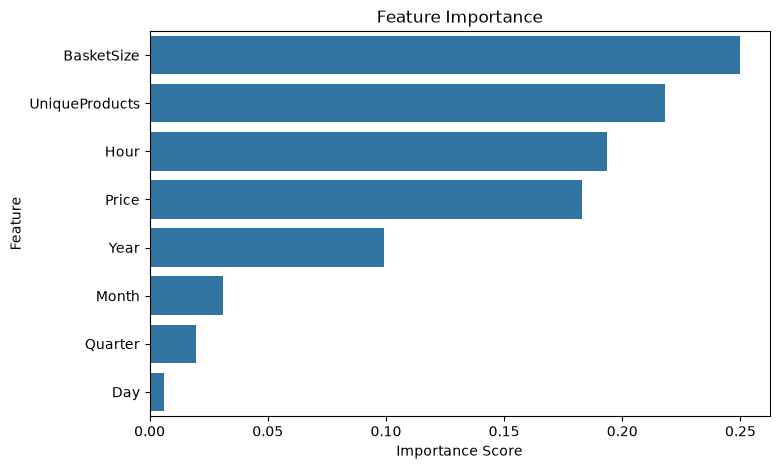

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Business Insights

- Basket Size is the most influential factor in predicting product demand, indicating that customers purchasing larger baskets tend to buy higher quantities.

- The number of unique products purchased also has a strong impact on demand prediction, highlighting the importance of product diversity in customer purchases.

- Purchase time (Hour) influences sales demand, suggesting that customer buying behavior varies throughout the day.

- Product price contributes significantly to demand prediction, indicating that pricing strategies affect customer purchasing patterns.

- The Random Forest model achieved an R² score of approximately 0.33, demonstrating a reasonable baseline performance for demand forecasting using historical retail transaction data.

In [15]:
importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)